              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



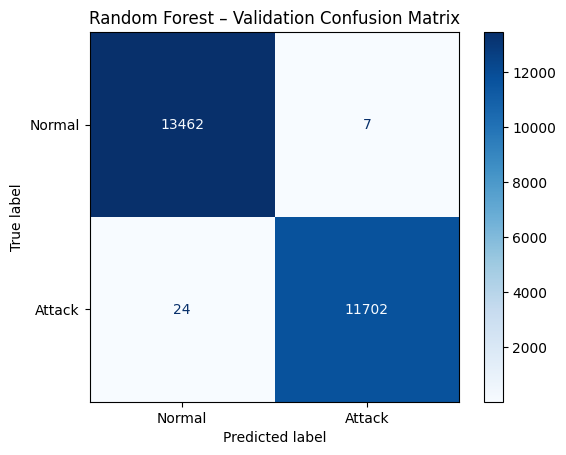

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_clf = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    n_jobs=-1,
    random_state=7,
)

rf_clf.fit(X_train_enc, y_train)

y_val_pred = rf_clf.predict(X_val_enc)
print(classification_report(y_val, y_val_pred, target_names=["Normal","Attack"]))

cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Attack"])
disp.plot(cmap="Blues")
plt.title("Random Forest – Validation Confusion Matrix")
plt.show()


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# Isolation Forest: train mostly on normal traffic
iso = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=7,
)
iso.fit(X_train_enc)

iso_raw = iso.predict(X_val_enc)          # 1 normal, -1 anomaly
iso_pred = (iso_raw == -1).astype(int)    # 1 → attack
print("IsolationForest accuracy:", accuracy_score(y_val, iso_pred))
print(classification_report(y_val, iso_pred, target_names=["Normal","Attack"]))


IsolationForest accuracy: 0.5600317523318119
              precision    recall  f1-score   support

      Normal       0.55      0.93      0.69     13469
      Attack       0.63      0.13      0.22     11726

    accuracy                           0.56     25195
   macro avg       0.59      0.53      0.46     25195
weighted avg       0.59      0.56      0.47     25195



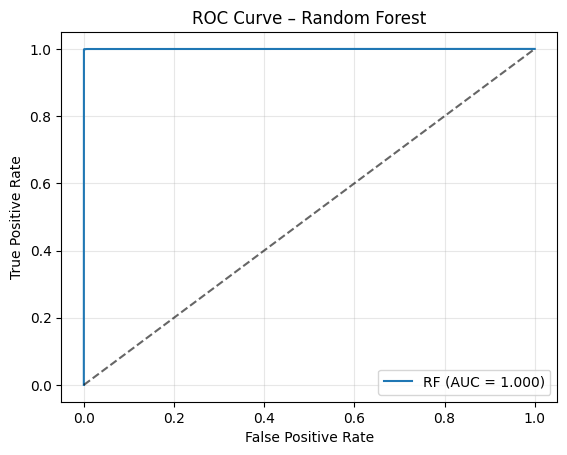

In [8]:
from sklearn.metrics import roc_curve, auc

rf_scores = rf_clf.predict_proba(X_val_enc)[:, 1]
fpr, tpr, _ = roc_curve(y_val, rf_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [9]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import pandas as pd

def summarize_binary(y_true, y_pred, name: str):
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, labels=[0, 1]
    )
    idx = ["Normal", "Attack"]
    summary = pd.DataFrame(
        {
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "support": support,
        },
        index=idx,
    )
    print(f"\n==== {name} ====")
    print(summary)
    return summary

rf_summary   = summarize_binary(y_val, y_val_pred, "Random Forest")
iso_summary  = summarize_binary(y_val, iso_pred, "Isolation Forest")
km_summary   = summarize_binary(y_val, km_pred, "KMeans")



==== Random Forest ====
        precision    recall        f1  support
Normal   0.998220  0.999480  0.998850    13469
Attack   0.999402  0.997953  0.998677    11726

==== Isolation Forest ====
        precision    recall        f1  support
Normal   0.552419  0.932660  0.693861    13469
Attack   0.630550  0.132014  0.218320    11726

==== KMeans ====
        precision  recall       f1  support
Normal    0.53459     1.0  0.69672    13469
Attack    0.00000     0.0  0.00000    11726


c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


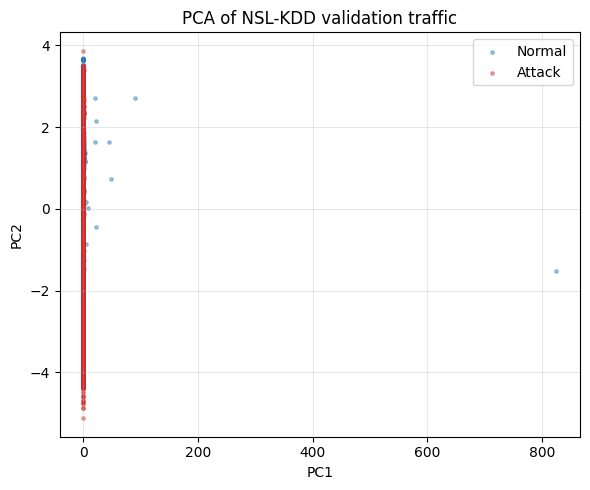

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=7)
X_val_2d = pca.fit_transform(X_val_enc.toarray() if hasattr(X_val_enc, "toarray") else X_val_enc)

df_pca = pd.DataFrame(
    {
        "pc1": X_val_2d[:, 0],
        "pc2": X_val_2d[:, 1],
        "label": y_val.replace({0: "Normal", 1: "Attack"}).values,
    }
)

plt.figure(figsize=(6, 5))
for label, color in [("Normal", "tab:blue"), ("Attack", "tab:red")]:
    subset = df_pca[df_pca["label"] == label]
    plt.scatter(subset["pc1"], subset["pc2"], s=6, alpha=0.4, label=label, c=color)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NSL-KDD validation traffic")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


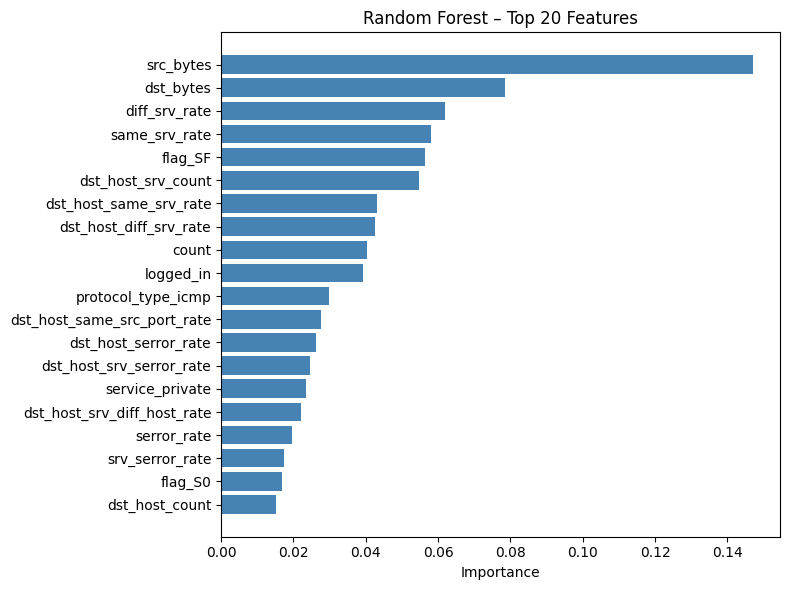

In [11]:
import numpy as np

# Get OHE feature names
ohe = transformer.named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))
num_feature_names = NUM_COLS
all_features = cat_feature_names + num_feature_names

importances = rf_clf.feature_importances_
order = np.argsort(importances)[-20:]  # top 20

plt.figure(figsize=(8, 6))
plt.barh(range(len(order)), importances[order], color="steelblue")
plt.yticks(range(len(order)), [all_features[i] for i in order])
plt.xlabel("Importance")
plt.title("Random Forest – Top 20 Features")
plt.tight_layout()
plt.show()


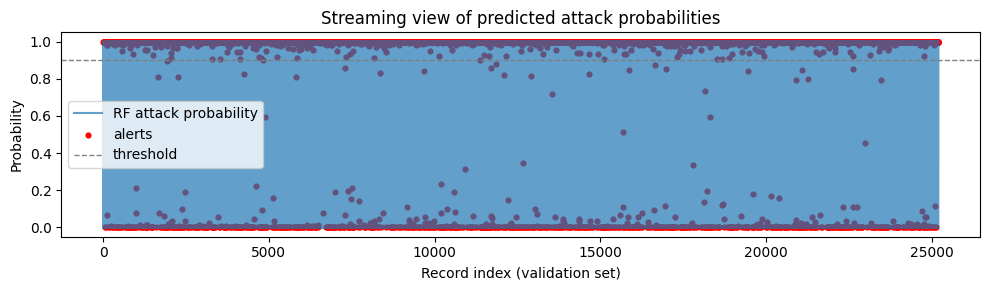

In [12]:
import itertools

rf_scores_stream = rf_clf.predict_proba(X_val_enc)[:, 1]
iso_labels_stream = iso.predict(X_val_enc)

records = list(zip(itertools.count(), rf_scores_stream, iso_labels_stream, y_val))

alert_indices = []
for idx, prob, iso_lab, true_y in records:
    is_alert = (prob > 0.9) or (iso_lab == -1)
    if is_alert:
        alert_indices.append(idx)

plt.figure(figsize=(10, 3))
plt.plot(rf_scores_stream, label="RF attack probability", alpha=0.7)
plt.scatter(alert_indices,
            [rf_scores_stream[i] for i in alert_indices],
            color="red", s=12, label="alerts")
plt.axhline(0.9, color="gray", linestyle="--", linewidth=1, label="threshold")
plt.xlabel("Record index (validation set)")
plt.ylabel("Probability")
plt.title("Streaming view of predicted attack probabilities")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
models_overview = pd.DataFrame(
    {
        "accuracy": [
            rf_summary.loc[["Normal","Attack"]].pipe(
                lambda df: (df["support"] * df["recall"]).sum() / df["support"].sum()
            ),
            iso_summary.loc[["Normal","Attack"]].pipe(
                lambda df: (df["support"] * df["recall"]).sum() / df["support"].sum()
            ),
            km_summary.loc[["Normal","Attack"]].pipe(
                lambda df: (df["support"] * df["recall"]).sum() / df["support"].sum()
            ),
        ],
        "model": ["Random Forest", "Isolation Forest", "KMeans"],
    }
).set_index("model")

print("\n=== Overall validation accuracy (approx.) ===")
print(models_overview.sort_values("accuracy", ascending=False))



=== Overall validation accuracy (approx.) ===
                  accuracy
model                     
Random Forest     0.998770
Isolation Forest  0.560032
KMeans            0.534590


In [14]:
# 1.1 Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 4)

# 1.2 Paths (adjust if needed)
ROOT = Path(".")
TRAIN_PLUS = ROOT / "KDDTrain+.txt"
TEST_PLUS  = ROOT / "KDDTest+.txt"

# 1.3 Column names
cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "attack","difficulty_level"
]

# 1.4 Load data
train_df = pd.read_csv(TRAIN_PLUS, header=None, names=cols)
test_df  = pd.read_csv(TEST_PLUS,  header=None, names=cols)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [15]:
# 2.1 Attack categories
DOS = ['back','land','neptune','pod','smurf','teardrop',
       'apache2','mailbomb','processtable','udpstorm','worm']
PROBE = ['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L = ['guess_passwd','ftp_write','imap','phf','multihop',
       'warezmaster','warezclient','spy','xlock','xsnoop',
       'snmpgetattack','snmpguess','httptunnel','sendmail','named']
U2R = ['rootkit','perl','loadmodule','ps','sqlattack']

def attack_group(label: str) -> str:
    if label in DOS:
        return "DoS"
    if label in PROBE:
        return "Probe"
    if label in R2L:
        return "R2L"
    if label in U2R:
        return "U2R"
    if label == "normal":
        return "Normal"
    return "Other"

for frame in (train_df, test_df):
    frame["attack_group"] = frame["attack"].map(attack_group)
    frame["binary_target"] = (frame["attack_group"] != "Normal").astype(int)

train_df[["attack","attack_group","binary_target"]].head()


,attack,attack_group,binary_target
0,normal,Normal,0
1,normal,Normal,0
2,neptune,DoS,1
3,normal,Normal,0
4,normal,Normal,0


C:\Users\hp\AppData\Local\Temp\ipykernel_12648\2155921625.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="attack_group", order=order, palette="viridis")


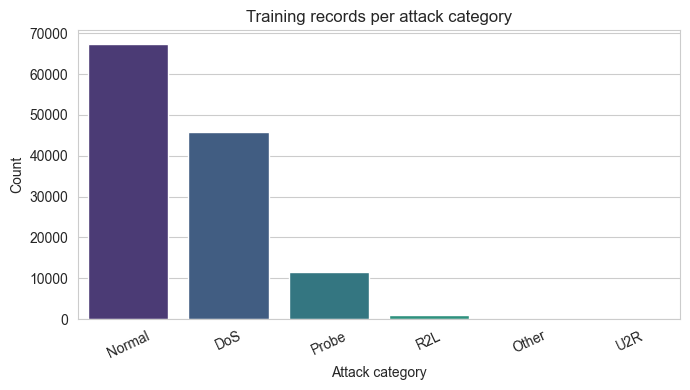

In [16]:
# 2.2 Category counts (bar)
plt.figure(figsize=(7,4))
order = train_df["attack_group"].value_counts().index
sns.countplot(data=train_df, x="attack_group", order=order, palette="viridis")
plt.title("Training records per attack category")
plt.xlabel("Attack category")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_12648\3674971932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_attacks.values, y=top_attacks.index, palette="magma")


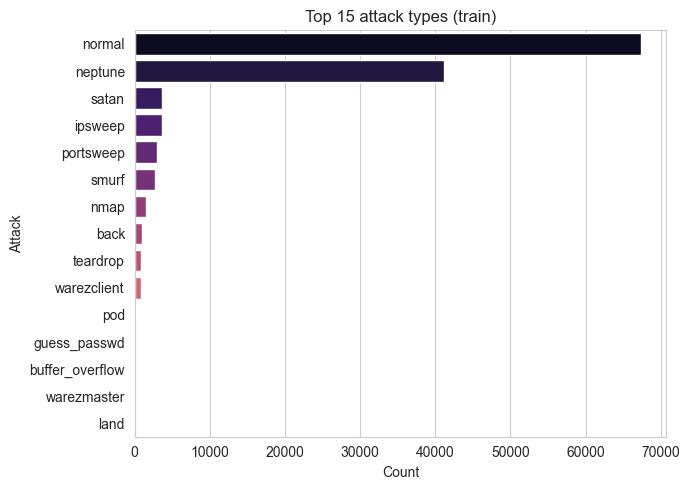

In [17]:
# 2.3 Fine‑grained top attacks
top_attacks = train_df["attack"].value_counts().head(15)

plt.figure(figsize=(7,5))
sns.barplot(x=top_attacks.values, y=top_attacks.index, palette="magma")
plt.xlabel("Count")
plt.ylabel("Attack")
plt.title("Top 15 attack types (train)")
plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_12648\3255370560.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x="protocol_type", ax=axes[0], palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_12648\3255370560.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_services.values, y=top_services.index, ax=axes[1], palette="Set3")


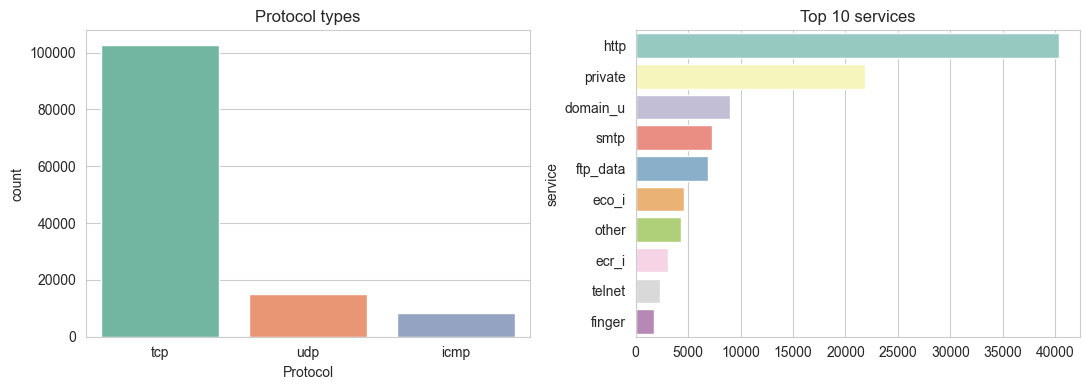

In [18]:
# 2.4 Protocol and service distributions
fig, axes = plt.subplots(1, 2, figsize=(11,4))

sns.countplot(data=train_df, x="protocol_type", ax=axes[0], palette="Set2")
axes[0].set_title("Protocol types")
axes[0].set_xlabel("Protocol")

top_services = train_df["service"].value_counts().head(10)
sns.barplot(x=top_services.values, y=top_services.index, ax=axes[1], palette="Set3")
axes[1].set_title("Top 10 services")

fig.tight_layout()
plt.show()


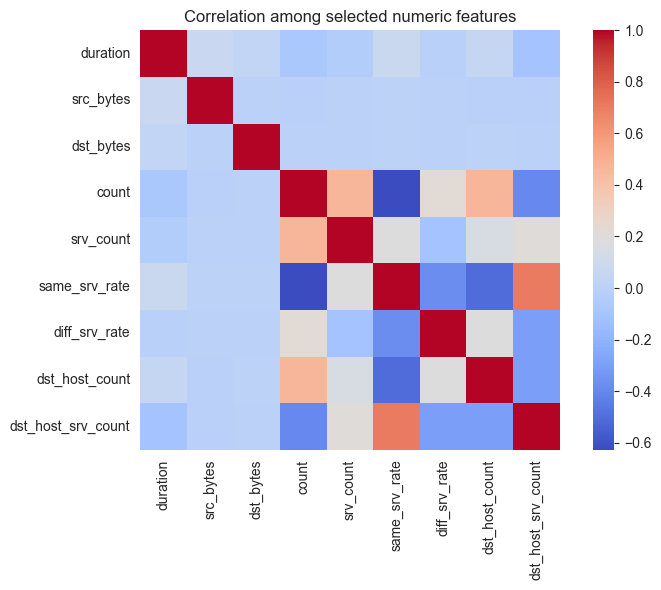

In [19]:
# 3.1 Correlation of selected key features
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.drop(["binary_target"])
key_subset = [
    "duration","src_bytes","dst_bytes","count","srv_count",
    "same_srv_rate","diff_srv_rate","dst_host_count","dst_host_srv_count"
]
corr = train_df[key_subset].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", square=True)
plt.title("Correlation among selected numeric features")
plt.tight_layout()
plt.show()


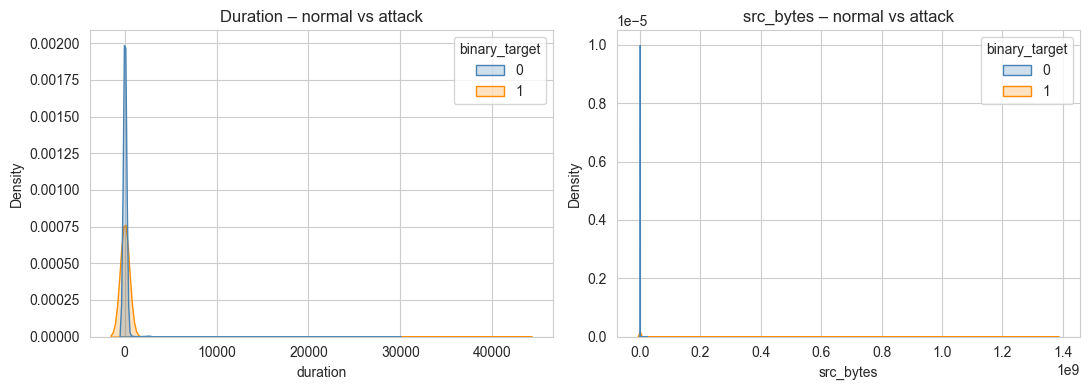

In [20]:
# 3.2 Distribution of duration and src_bytes per class
sample = train_df.sample(min(30000, len(train_df)), random_state=10)

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.kdeplot(
    data=sample, x="duration", hue="binary_target",
    fill=True, common_norm=False, ax=axes[0],
    palette={0:"steelblue",1:"darkorange"}
)
axes[0].set_title("Duration – normal vs attack")
axes[0].set_xlabel("duration")

sns.kdeplot(
    data=sample, x="src_bytes", hue="binary_target",
    fill=True, common_norm=False, ax=axes[1],
    palette={0:"steelblue",1:"darkorange"}
)
axes[1].set_title("src_bytes – normal vs attack")
axes[1].set_xlabel("src_bytes")

fig.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

feature_cols = [c for c in cols if c not in ("attack","difficulty_level")]
cat_cols = ["protocol_type","service","flag"]
num_cols = [c for c in feature_cols if c not in cat_cols]

X = train_df[feature_cols]
y = train_df["binary_target"]

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.25, random_state=22, stratify=y
)

pre = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("numeric", StandardScaler(), num_cols),
    ]
)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

rf_pipeline = Pipeline(
    steps=[
        ("prep", pre),
        ("clf", RandomForestClassifier(
            n_estimators=220,
            n_jobs=-1,
            random_state=22
        )),
    ]
)

rf_pipeline.fit(X_tr, y_tr)
y_val_pred = rf_pipeline.predict(X_val)

print("Random Forest (validation):")
print(classification_report(y_val, y_val_pred, target_names=["Normal","Attack"]))


Random Forest (validation):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     16836
      Attack       1.00      1.00      1.00     14658

    accuracy                           1.00     31494
   macro avg       1.00      1.00      1.00     31494
weighted avg       1.00      1.00      1.00     31494



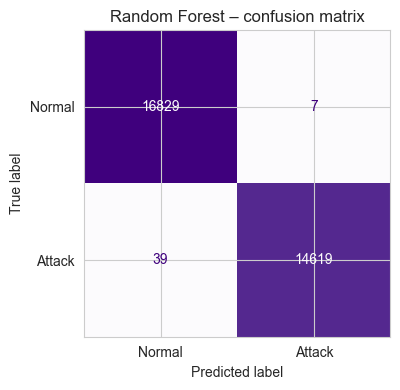

In [23]:
# 5.1 Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal","Attack"])
disp.plot(cmap="Purples", ax=ax, colorbar=False)
ax.set_title("Random Forest – confusion matrix")
plt.tight_layout()
plt.show()


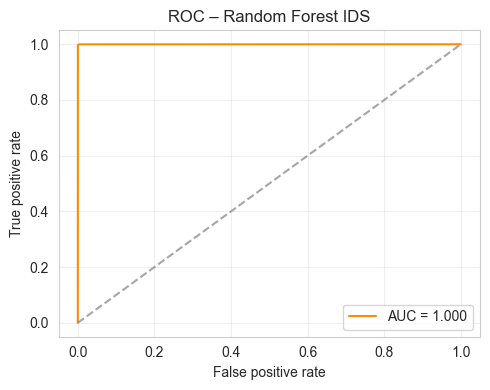

In [24]:
# 5.2 ROC curve
y_val_scores = rf_pipeline.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray", alpha=0.7)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC – Random Forest IDS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# Use fitted preprocessor from RF pipeline
prep_fitted = rf_pipeline.named_steps["prep"]
X_tr_enc = prep_fitted.transform(X_tr)
X_val_enc = prep_fitted.transform(X_val)


In [26]:
# 6.1 Isolation Forest
iso = IsolationForest(
    n_estimators=180,
    contamination=0.08,
    random_state=22
)
iso.fit(X_tr_enc)

iso_raw = iso.predict(X_val_enc)       # 1 = normal, -1 = anomaly
iso_pred = (iso_raw == -1).astype(int) # 1 = attack

print("Isolation Forest accuracy:", accuracy_score(y_val, iso_pred))
print(classification_report(y_val, iso_pred, target_names=["Normal","Attack"]))


Isolation Forest accuracy: 0.5661078300628691
              precision    recall  f1-score   support

      Normal       0.55      0.96      0.70     16836
      Attack       0.70      0.12      0.20     14658

    accuracy                           0.57     31494
   macro avg       0.63      0.54      0.45     31494
weighted avg       0.62      0.57      0.47     31494



In [27]:
# 6.2 KMeans clustering
km = KMeans(n_clusters=2, random_state=22)
clusters = km.fit_predict(X_val_enc)

cluster_to_label = {}
for cl in np.unique(clusters):
    majority = int(round(y_val[clusters == cl].mean()))
    cluster_to_label[cl] = majority

km_pred = np.vectorize(cluster_to_label.get)(clusters)

print("KMeans accuracy:", accuracy_score(y_val, km_pred))
print(classification_report(y_val, km_pred, target_names=["Normal","Attack"]))


KMeans accuracy: 0.8865815710929066
              precision    recall  f1-score   support

      Normal       0.83      1.00      0.90     16836
      Attack       1.00      0.76      0.86     14658

    accuracy                           0.89     31494
   macro avg       0.91      0.88      0.88     31494
weighted avg       0.91      0.89      0.88     31494



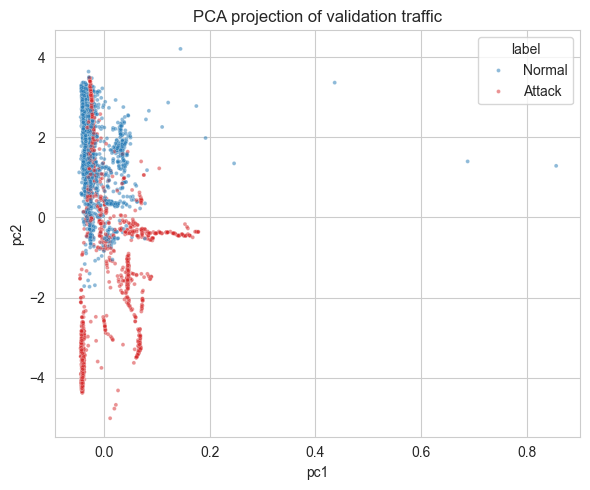

In [28]:
from sklearn.decomposition import PCA

dense_val = X_val_enc.toarray() if hasattr(X_val_enc, "toarray") else X_val_enc
pca = PCA(n_components=2, random_state=22)
val_2d = pca.fit_transform(dense_val)

sub_idx = np.random.RandomState(22).choice(len(val_2d), size=min(8000, len(val_2d)), replace=False)

pca_df = pd.DataFrame({
    "pc1": val_2d[sub_idx, 0],
    "pc2": val_2d[sub_idx, 1],
    "label": y_val.iloc[sub_idx].replace({0:"Normal",1:"Attack"}).values
})

plt.figure(figsize=(6,5))
sns.scatterplot(
    data=pca_df, x="pc1", y="pc2", hue="label",
    palette={"Normal":"#1f77b4","Attack":"#d62728"},
    s=8, alpha=0.5
)
plt.title("PCA projection of validation traffic")
plt.tight_layout()
plt.show()


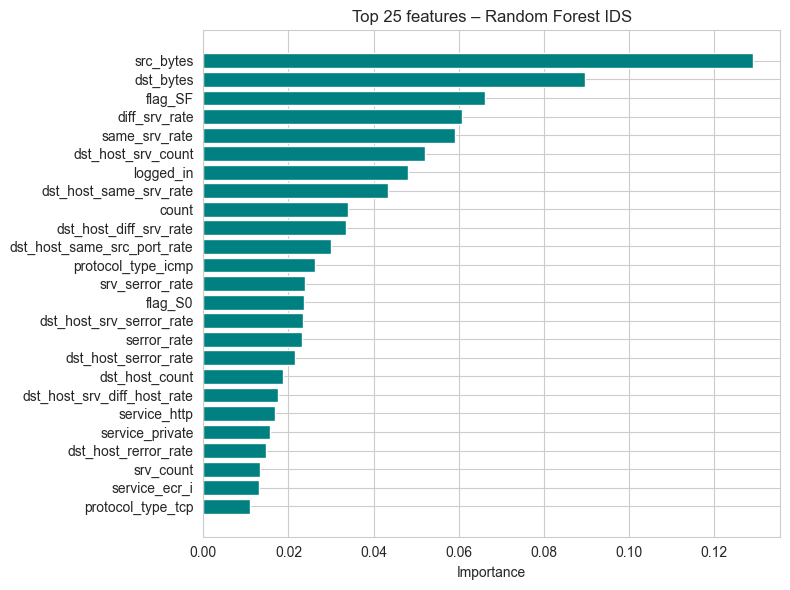

In [29]:
rf_clf = rf_pipeline.named_steps["clf"]
ohe = prep_fitted.named_transformers_["categorical"]
cat_names = list(ohe.get_feature_names_out(cat_cols))
all_feature_names = cat_names + num_cols

importances = rf_clf.feature_importances_
top_idx = np.argsort(importances)[-25:]

plt.figure(figsize=(8,6))
plt.barh(range(len(top_idx)), importances[top_idx], color="teal")
plt.yticks(range(len(top_idx)), [all_feature_names[i] for i in top_idx])
plt.xlabel("Importance")
plt.title("Top 25 features – Random Forest IDS")
plt.tight_layout()
plt.show()


In [30]:
from sklearn.metrics import precision_recall_fscore_support
import joblib

def approx_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

rf_acc  = approx_accuracy(y_val, y_val_pred)
iso_acc = approx_accuracy(y_val, iso_pred)
km_acc  = approx_accuracy(y_val, km_pred)

summary_df = pd.DataFrame(
    {
        "model": ["RandomForest","IsolationForest","KMeans"],
        "accuracy": [rf_acc, iso_acc, km_acc],
    }
).set_index("model")

summary_df


,accuracy
model,
RandomForest,0.998539
IsolationForest,0.566108
KMeans,0.886582


In [31]:
# save models and preprocessor
joblib.dump(rf_pipeline, "ids_rf_pipeline.joblib")
joblib.dump(iso, "ids_iso_forest.joblib")
joblib.dump(km, "ids_kmeans.joblib")


['ids_kmeans.joblib']

In [32]:
X_test = test_df[feature_cols]
y_test = (test_df["attack_group"] != "Normal").astype(int)

X_test_enc = prep_fitted.transform(X_test)

rf_scores_test = rf_pipeline.named_steps["clf"].predict_proba(X_test_enc)[:, 1]
iso_test_raw   = iso.predict(X_test_enc)

alert_rows = []
for idx, (score, iso_lbl, true_lbl) in enumerate(zip(rf_scores_test, iso_test_raw, y_test)):
    suspicious = (score > 0.90) or (iso_lbl == -1)
    if suspicious:
        alert_rows.append(
            {
                "index": idx,
                "rf_prob_attack": float(score),
                "iso_flag": int(iso_lbl),
                "true_label": int(true_lbl),
            }
        )

alerts_df = pd.DataFrame(alert_rows)
alerts_df.to_csv("stream_alerts.csv", index=False)
alerts_df.head()
print("Total alerts:", len(alerts_df))


Total alerts: 8891


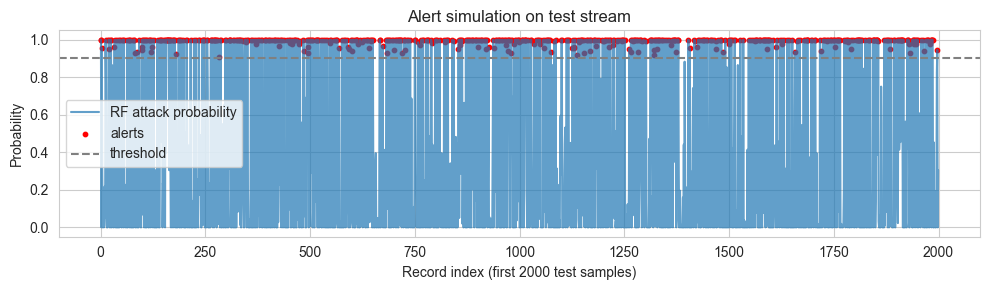

In [33]:
# visualize alert threshold over stream
plt.figure(figsize=(10,3))
plt.plot(rf_scores_test[:2000], label="RF attack probability", alpha=0.7)
threshold = 0.9
alert_idx = [i for i, s in enumerate(rf_scores_test[:2000]) if s > threshold]
plt.scatter(alert_idx, [rf_scores_test[i] for i in alert_idx],
            color="red", s=10, label="alerts")
plt.axhline(threshold, linestyle="--", color="gray", label="threshold")
plt.xlabel("Record index (first 2000 test samples)")
plt.ylabel("Probability")
plt.title("Alert simulation on test stream")
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
from sklearn.metrics import classification_report

y_test_pred = rf_pipeline.predict(X_test)
print("Binary intrusion detection on test set:")
print(classification_report(y_test, y_test_pred, target_names=["Normal","Attack"]))


Binary intrusion detection on test set:
              precision    recall  f1-score   support

      Normal       0.65      0.97      0.78      9711
      Attack       0.97      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



In [36]:
# Multi‑class attack_group classification (optional)
y_train_group = train_df["attack_group"]

X_tr_full, _, y_tr_group, _ = train_test_split(
    X, y_train_group, test_size=0.25, random_state=22, stratify=y_train_group
)

rf_multi = Pipeline(
    steps=[
        ("prep", pre),
        ("clf", RandomForestClassifier(
            n_estimators=240,
            n_jobs=-1,
            random_state=33
        )),
    ]
)

rf_multi.fit(X_tr_full, y_tr_group)

# define test labels here
y_test_group = test_df["attack_group"]

y_test_group_pred = rf_multi.predict(X_test)
print("Attack category classification on test set:")
print(classification_report(y_test_group, y_test_group_pred))


Attack category classification on test set:
              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7460
      Normal       0.64      0.97      0.77      9711
       Other       1.00      0.03      0.06        33
       Probe       0.86      0.60      0.70      2421
         R2L       0.96      0.02      0.04      2885
         U2R       0.25      0.03      0.05        34

    accuracy                           0.74     22544
   macro avg       0.78      0.40      0.41     22544
weighted avg       0.81      0.74      0.70     22544



In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.graph_objects as go
import plotly.express as px
import dash
import dash_bootstrap_components as dbc

from plotly.subplots import make_subplots
from dash import dcc, html, Input, Output
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [45]:
file_path = r"C:\Users\hp\OneDrive\Desktop\anshnew\infosys\nsl-kdd\KDDTest+.txt"
df = pd.read_csv(file_path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [47]:
# Column names (41 features)
feature_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate"
]

In [48]:
df.columns = feature_names + ["attack", "difficulty_level"]
columns = feature_names + ["attack", "difficulty_level"]

df.columns = columns

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty_level
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [49]:
dos_attacks = ['back','land','neptune','pod','smurf','teardrop','apache2',
               'mailbomb','processtable','udpstorm','worm']
probe_attacks = ['satan','ipsweep','nmap','portsweep','mscan','saint']
r2l_attacks = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster',
               'warezclient','spy','xlock','xsnoop','snmpgetattack','snmpguess',
               'httptunnel','sendmail','named']
u2r_attacks = ['rootkit','perl','loadmodule','ps','sqlattack','buffer_overflow']

def map_attack_category(label: str) -> str:
    if label in dos_attacks:
        return "DoS"
    elif label in probe_attacks:
        return "Probe"
    elif label in r2l_attacks:
        return "R2L"
    elif label in u2r_attacks:
        return "U2R"
    else:
        return "Normal"

df["attack_category"] = df["attack"].apply(map_attack_category)
df["binary_label"] = df["attack_category"].apply(lambda x: 0 if x == "Normal" else 1)   


print("\n=== ATTACK CATEGORY DISTRIBUTION ===")
print(df["attack_category"].value_counts())
print("\nAttack Category Shape:", df["attack_category"].shape)


=== ATTACK CATEGORY DISTRIBUTION ===
attack_category
Normal    9724
DoS       7460
R2L       2885
Probe     2421
U2R         54
Name: count, dtype: int64

Attack Category Shape: (22544,)


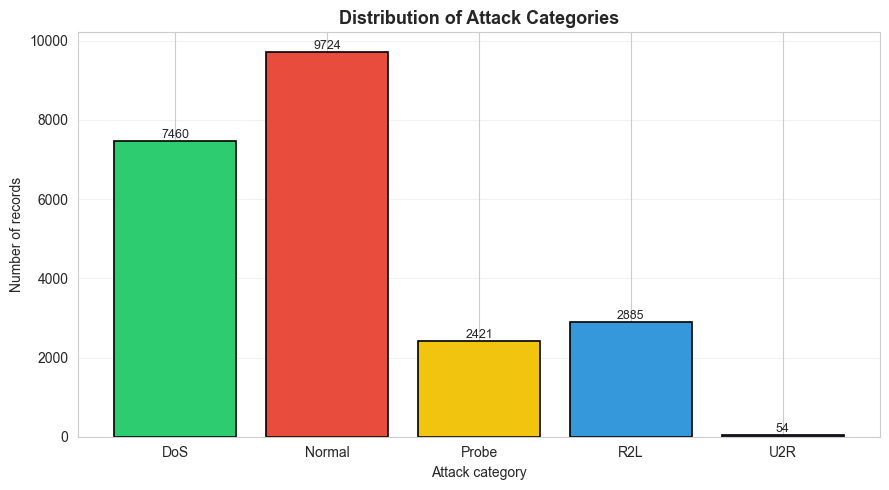

In [50]:
import matplotlib.pyplot as plt

# Count categories first
cat_counts = df["attack_category"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cat_counts.index,
    cat_counts.values,
    color=["#2ecc71", "#e74c3c", "#f1c40f", "#3498db", "#9b59b6"],
    edgecolor="black",
    linewidth=1.2
)

ax.set_title("Distribution of Attack Categories", fontsize=13, fontweight="bold")
ax.set_xlabel("Attack category")
ax.set_ylabel("Number of records")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


In [51]:
df["attack_category"] = df["attack"].apply(map_attack_category)
df[["attack", "attack_category"]].head()

,attack,attack_category
0,neptune,DoS
1,neptune,DoS
2,normal,Normal
3,saint,Probe
4,mscan,Probe


In [52]:
print("\n=== DATA PREPROCESSING STEP: CLEANING ===")
print(f"Initial dataset shape: {df.shape}")

# 1. Remove duplicate rows
n_before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {n_before - len(df)}")
print(f"Shape after de-duplication: {df.shape}")

# 2. Drop columns not needed for modeling
cols_to_remove = ["num_outbound_cmds", "is_host_login", "difficulty_level"]
cols_to_remove = [c for c in cols_to_remove if c in df.columns]

df = df.drop(columns=cols_to_remove)
print(f"Columns dropped: {cols_to_remove}")
print(f"Shape after column drop: {df.shape}")

# 3. Missing value treatment
print("\nColumns with missing values (before):")
na_counts = df.isna().sum()
print(na_counts[na_counts > 0])

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode().iloc[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

print("\nMissing values after imputation:", int(df.isna().sum().sum()))



=== DATA PREPROCESSING STEP: CLEANING ===
Initial dataset shape: (22544, 45)
Duplicates removed: 0
Shape after de-duplication: (22544, 45)
Columns dropped: ['num_outbound_cmds', 'is_host_login', 'difficulty_level']
Shape after column drop: (22544, 42)

Columns with missing values (before):
Series([], dtype: int64)

Missing values after imputation: 0


In [53]:
# === DEFINE FEATURE TYPES EXPLICITLY ===
cat_cols = ["protocol_type", "service", "flag"]
num_cols = [
    "duration", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
    "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
]

# keep only columns actually present in df
cat_cols = [c for c in cat_cols if c in df.columns]
num_cols = [c for c in num_cols if c in df.columns]

print("\n=== FEATURE SUMMARY ===")
print(f"Total usable features: {len(cat_cols) + len(num_cols)}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
print(f"Numerical  ({len(num_cols)}): {num_cols}")

# ---------------------------
# Build X, y for modeling
# ---------------------------
drop_targets = [c for c in ["attack", "attack_category", "binary_label"]
                if c in df.columns]

X = df.drop(columns=drop_targets)
y = df["attack_category"]

print(f"\nShapes -> X: {X.shape}, y: {y.shape}")



=== FEATURE SUMMARY ===
Total usable features: 39
Categorical (3): ['protocol_type', 'service', 'flag']
Numerical  (36): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Shapes -> X: (22544, 39), y: (22544,)


In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Build preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num_scaler", StandardScaler(), num_cols),          # numeric features
        ("cat_ohe", OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False), cat_cols),
    ],
    remainder="drop"
)

# Fit on full feature matrix X and transform
X_ready = preprocess.fit_transform(X)
print(f"\nPreprocessed feature matrix shape: {X_ready.shape}")


Preprocessed feature matrix shape: (22544, 114)


In [55]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Step 1: create test set (20%)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_ready,
    y,
    test_size=0.2,
    stratify=y,
    random_state=123
)

# Step 2: split remaining 80% into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=0.25,          # 25% of 80%  -> 20% of total
    stratify=y_tmp,
    random_state=123
)

print("\n--- DATA SPLIT DETAILS ---")
print(f"Train set : {X_train.shape[0]} samples")
print(f"Val set   : {X_val.shape[0]} samples")
print(f"Test set  : {X_test.shape[0]} samples")

print("\nTraining label distribution:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))


--- DATA SPLIT DETAILS ---
Train set : 13526 samples
Val set   : 4509 samples
Test set  : 4509 samples

Training label distribution:
attack_category
Normal    0.431
DoS       0.331
R2L       0.128
Probe     0.107
U2R       0.002
Name: proportion, dtype: float64


Per‑class performance metrics:
    class  precision    recall  f1-score  support
0     DoS   0.997988  0.997319  0.997653   1492.0
1  Normal   0.982079  0.986118  0.984094   1945.0
2   Probe   0.993763  0.987603  0.990674    484.0
3     R2L   0.960139  0.960139  0.960139    577.0
4     U2R   0.714286  0.454545  0.555556     11.0


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


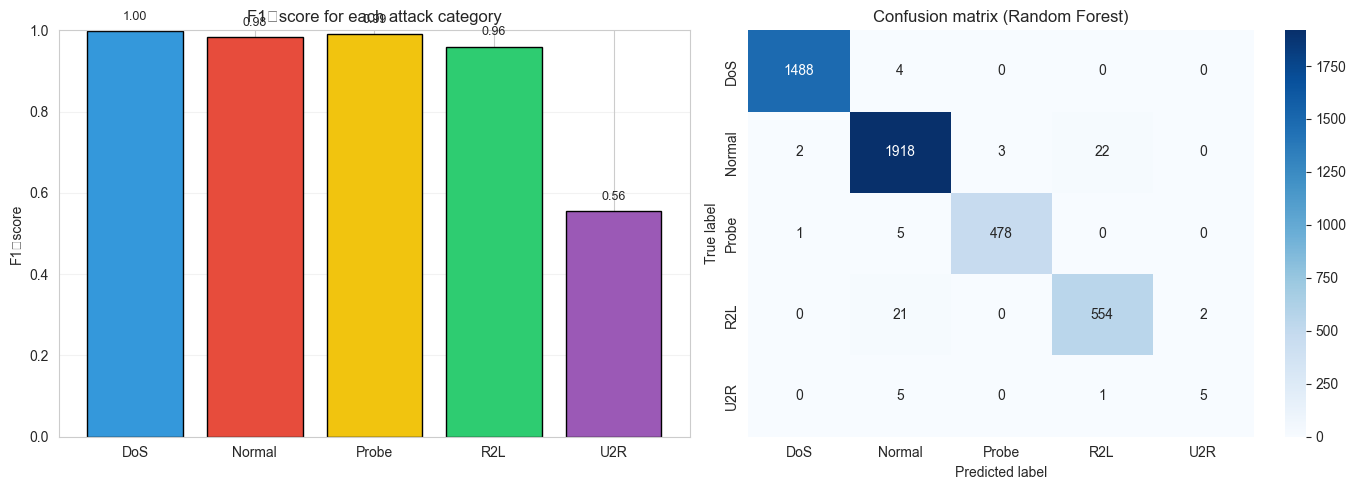

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Train RF on current split (if not already trained)
rf_clf = RandomForestClassifier(
    n_estimators=120,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

# Predictions
y_pred = rf_clf.predict(X_test)

# -----------------------------
# 1. Per‑class precision/recall/F1 table
# -----------------------------
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

# Drop micro/weighted avg rows, keep only real classes
perf_df = (
    pd.DataFrame(report_dict)
    .T
    .reset_index()
    .rename(columns={"index": "class"})
)
perf_df = perf_df[perf_df["class"].isin(sorted(y_test.unique()))]

print("Per‑class performance metrics:")
print(perf_df[["class", "precision", "recall", "f1-score", "support"]])

# -----------------------------
# 2. Visualizations
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: F1 per class
ax1.bar(
    perf_df["class"],
    perf_df["f1-score"],
    color=["#3498db", "#e74c3c", "#f1c40f", "#2ecc71", "#9b59b6"],
    edgecolor="black"
)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel("F1‑score")
ax1.set_title("F1‑score for each attack category")
for idx, val in enumerate(perf_df["f1-score"]):
    ax1.text(idx, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)
ax1.grid(axis="y", alpha=0.25)

# Heatmap: confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=sorted(y_test.unique()))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique()),
    ax=ax2
)
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")
ax2.set_title("Confusion matrix (Random Forest)")

plt.tight_layout()
plt.show()


In [59]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. DERIVED TRAFFIC FEATURES
# -----------------------------

# 1) Overall volume exchanged between endpoints
df["bytes_total"] = df["src_bytes"] + df["dst_bytes"]

# 2) Skew of traffic from source to destination
#    (add small constant to avoid division by zero)
df["src_dst_ratio"] = (df["src_bytes"] + 1) / (df["dst_bytes"] + 1)

# 3) Combined error behaviour across connection types
df["error_rate_agg"] = (
    df["serror_rate"]
    + df["rerror_rate"]
    + df["srv_serror_rate"]
    + df["srv_rerror_rate"]
) / 4.0

extra_num_feats = ["bytes_total", "src_dst_ratio", "error_rate_agg"]

# extend numeric feature list if needed
for col in extra_num_feats:
    if col not in num_cols:
        num_cols.append(col)

print(f"New engineered numeric features: {extra_num_feats}")
print(f"Total numeric features now: {len(num_cols)}")


New engineered numeric features: ['bytes_total', 'src_dst_ratio', 'error_rate_agg']
Total numeric features now: 39



Top 20 numeric features correlated with attack/normal:
error_rate_agg              0.612467
dst_host_srv_count         -0.591953
dst_host_same_srv_rate     -0.575362
logged_in                  -0.551836
same_srv_rate              -0.511284
dst_host_rerror_rate        0.488770
rerror_rate                 0.481669
srv_rerror_rate             0.475128
dst_host_srv_rerror_rate    0.472972
dst_host_count              0.353975
dst_host_srv_serror_rate    0.300614
dst_host_serror_rate        0.299139
serror_rate                 0.294121
srv_serror_rate             0.293500
count                       0.281853
diff_srv_rate               0.259038
dst_host_diff_srv_rate      0.252340
is_guest_login              0.125279
num_failed_logins           0.118858
duration                    0.106278
Name: binary_label, dtype: float64


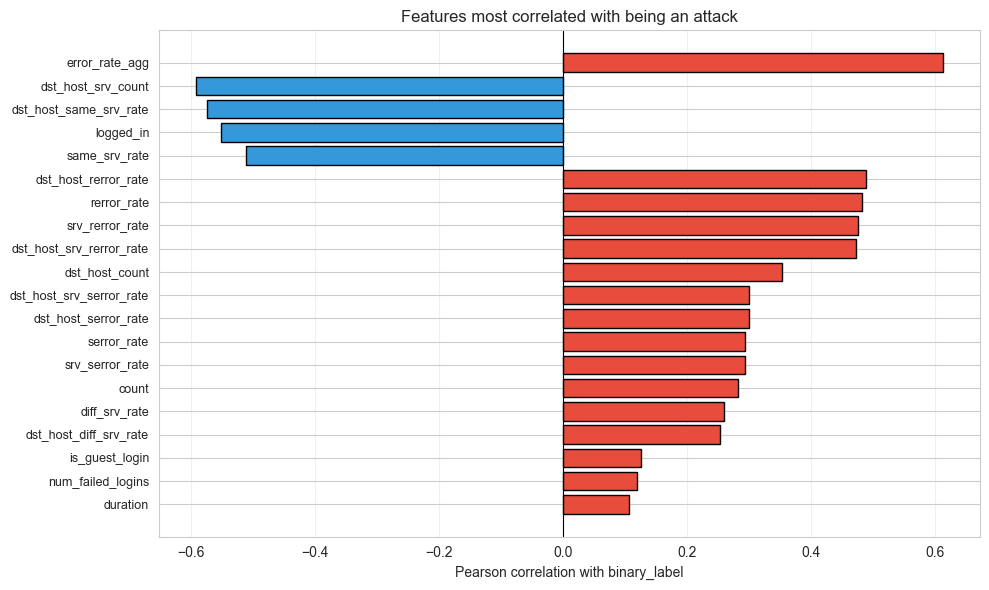

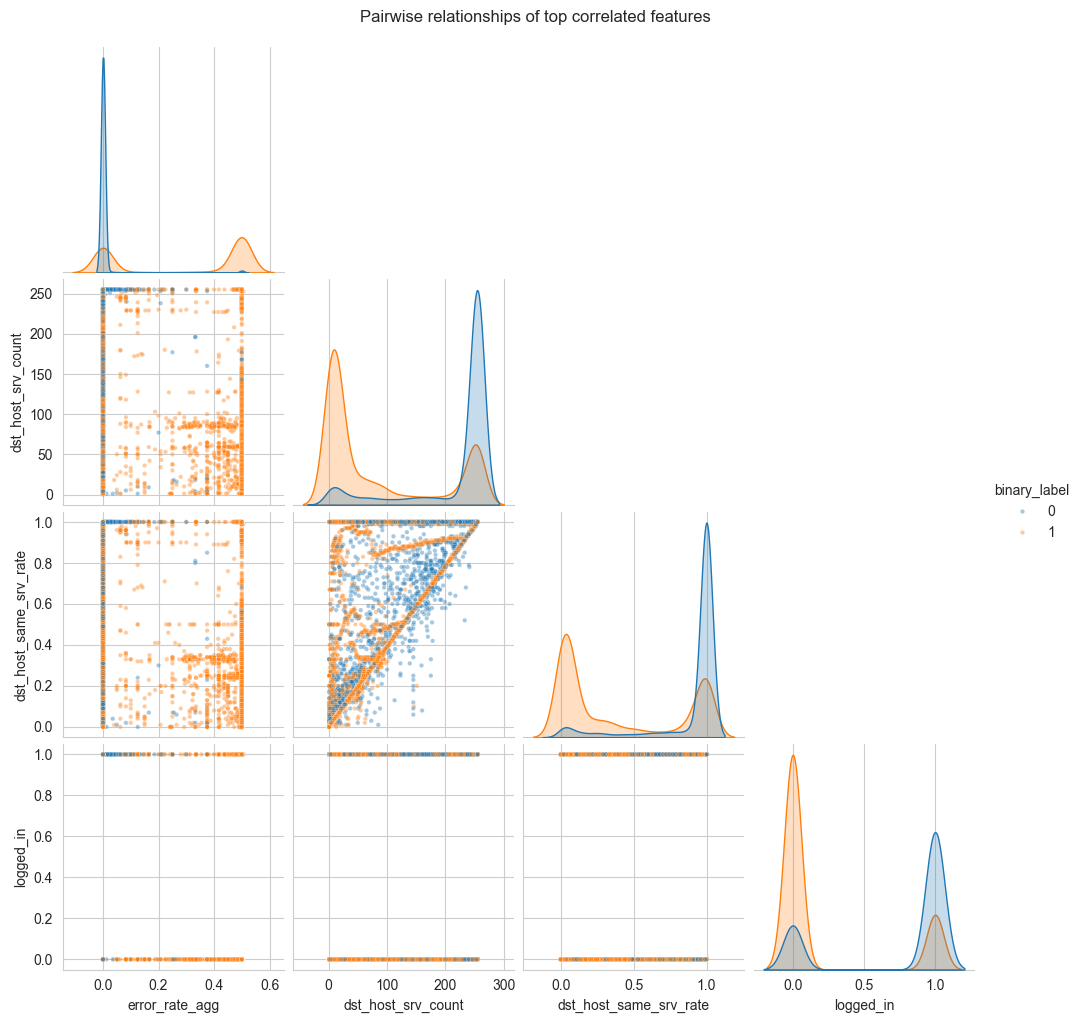

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assume you have a binary label: 1 = attack, 0 = normal
# If not present, create it from attack_category
if "binary_label" not in df.columns:
    df["binary_label"] = (df["attack_category"] != "Normal").astype(int)

# -----------------------------
# 1. Correlation with target (binary_label)
# -----------------------------
num_df = df[num_cols + ["binary_label"]].copy()
corr_with_target = num_df.corr()["binary_label"].drop("binary_label")

# Sort by absolute correlation strength
corr_sorted = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

top_n = 20
top_corr = corr_sorted.head(top_n)

print(f"\nTop {top_n} numeric features correlated with attack/normal:")
print(top_corr)

# -----------------------------
# 2. Visualization: bar plot of correlation with target
# -----------------------------
plt.figure(figsize=(10, 6))
colors = np.where(top_corr > 0, "#e74c3c", "#3498db")

plt.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor="black")
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=9)
plt.xlabel("Pearson correlation with binary_label")
plt.title("Features most correlated with being an attack")
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 3. Optional: pairplot of top 4 features vs target
# -----------------------------
top4 = top_corr.index[:4].tolist()

sns.pairplot(
    df[top4 + ["binary_label"]],
    hue="binary_label",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 10},
    corner=True
)
plt.suptitle("Pairwise relationships of top correlated features", y=1.02)
plt.show()


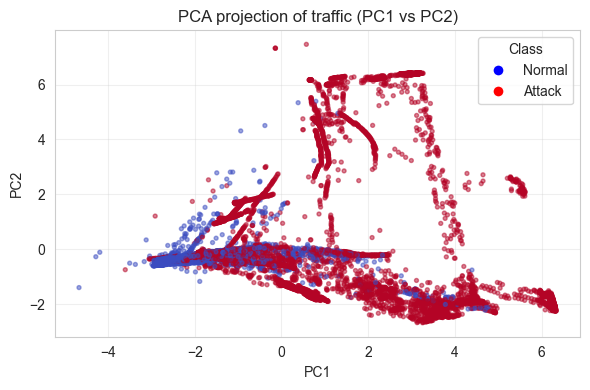

In [63]:
# Existing scatter
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df["binary_label"],
    cmap="coolwarm",
    s=8,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of traffic (PC1 vs PC2)")

# --- FIXED LEGEND ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Normal',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Attack',
           markerfacecolor='red', markersize=8),
]

plt.legend(handles=legend_elements, title="Class", loc="best")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== Benchmarking classifiers on test set ===

Fitting LogReg_l2 ...
  Accuracy : 0.9641
  Precision: 0.9265
  Recall   : 0.8629
  F1-score : 0.8833
--------------------------------------------------
Fitting RF_200_depth20 ...
  Accuracy : 0.9851
  Precision: 0.9069
  Recall   : 0.8413
  F1-score : 0.8618
--------------------------------------------------
Fitting SVM_rbf_C2 ...
  Accuracy : 0.9736
  Precision: 0.9722
  Recall   : 0.8683
  F1-score : 0.8997
--------------------------------------------------

=== Summary of model performance (macro metrics) ===
                Accuracy  Precision    Recall        F1
LogReg_l2       0.964072   0.926500  0.862947  0.883347
RF_200_depth20  0.985141   0.906877  0.841278  0.861802
SVM_rbf_C2      0.973608   0.972199  0.868276  0.899721


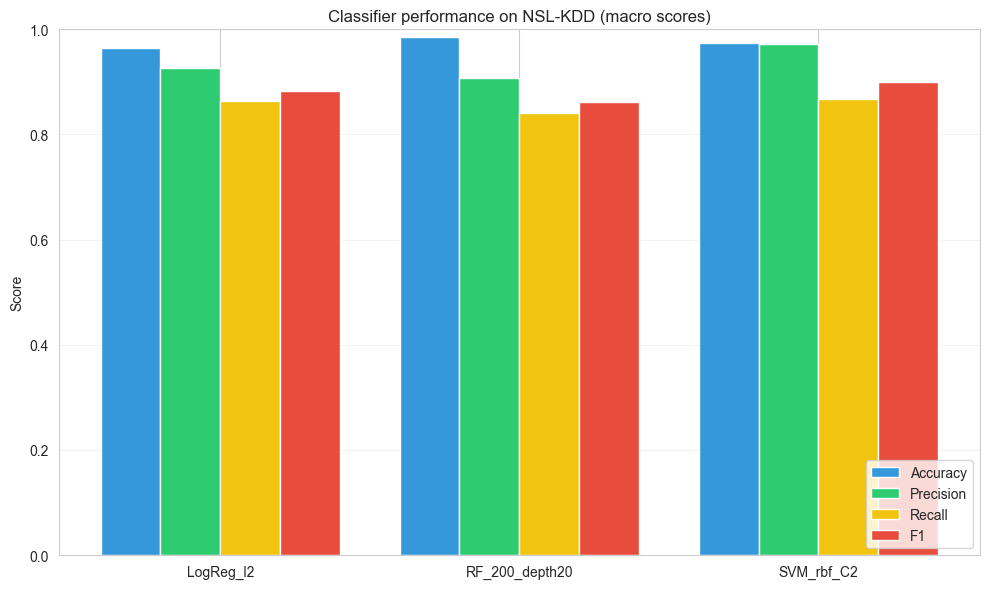

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Define candidate models
# -----------------------------
model_specs = {
    "LogReg_l2": LogisticRegression(
        max_iter=1500,
        penalty="l2",
        C=0.5,
        n_jobs=-1,
        random_state=42
    ),
    "RF_200_depth20": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=3,
        random_state=42,
        n_jobs=-1
    ),
    "SVM_rbf_C2": SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        random_state=42
    )
}

metrics_store = {}

print("\n=== Benchmarking classifiers on test set ===\n")

# -----------------------------
# 2. Training + evaluation loop
# -----------------------------
for model_name, clf in model_specs.items():
    print(f"Fitting {model_name} ...")
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    metrics_store[model_name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 50)

# -----------------------------
# 3. Results table
# -----------------------------
scores_df = pd.DataFrame(metrics_store).T
print("\n=== Summary of model performance (macro metrics) ===")
print(scores_df)

# -----------------------------
# 4. Visualization: grouped bar plot
# -----------------------------
plt.figure(figsize=(10, 6))

bar_width = 0.2
indices = np.arange(len(scores_df))

plt.bar(indices - bar_width*1.5, scores_df["Accuracy"], width=bar_width,
        label="Accuracy", color="#3498db")
plt.bar(indices - bar_width*0.5, scores_df["Precision"], width=bar_width,
        label="Precision", color="#2ecc71")
plt.bar(indices + bar_width*0.5, scores_df["Recall"], width=bar_width,
        label="Recall", color="#f1c40f")
plt.bar(indices + bar_width*1.5, scores_df["F1"], width=bar_width,
        label="F1", color="#e74c3c")

plt.xticks(indices, scores_df.index, rotation=0)
plt.ylabel("Score")
plt.ylim(0.0, 1.0)
plt.title("Classifier performance on NSL-KDD (macro scores)")
plt.grid(axis="y", alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. DEFINE MODELS (TUNED VARIANTS)
# -----------------------------
models = {
    "LogReg (C=0.7)": LogisticRegression(
        max_iter=1500,
        C=0.7,
        penalty="l2",
        n_jobs=-1,
        random_state=42
    ),
    "RF (200 trees)": RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_split=3,
        random_state=42,
        n_jobs=-1
    ),
    "SVM (rbf, C=2)": SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        random_state=42
    )
}

# -----------------------------
# 2. TRAINING LOOP
# -----------------------------
results = {}

print("\n=== Training baseline models ===\n")

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print("-" * 55)

# -----------------------------
# 3. COMPARISON DATAFRAME
# -----------------------------
results_df = pd.DataFrame(results).T
print("\n=== FINAL COMPARISON TABLE (macro metrics) ===")
print(results_df)

# -----------------------------
# 4. VISUALIZATION (GROUPED BARS)
# -----------------------------
plt.figure(figsize=(10, 6))

idx = np.arange(len(results_df))
width = 0.2

plt.bar(idx - 1.5*width, results_df["Accuracy"],  width=width, label="Accuracy",  color="#2980b9")
plt.bar(idx - 0.5*width, results_df["Precision"], width=width, label="Precision", color="#27ae60")
plt.bar(idx + 0.5*width, results_df["Recall"],    width=width, label="Recall",    color="#f1c40f")
plt.bar(idx + 1.5*width, results_df["F1"],       width=width, label="F1",        color="#c0392b")

plt.xticks(idx, results_df.index, rotation=0)
plt.ylabel("Score")
plt.ylim(0.0, 1.0)
plt.title("Model performance on NSL-KDD (macro metrics)")
plt.grid(axis="y", alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



=== Training baseline models ===

Training LogReg (C=0.7) ...
  Accuracy : 0.9641
  Precision: 0.9263
  Recall   : 0.8629
  F1-score : 0.8832
-------------------------------------------------------
Training RF (200 trees) ...
